In [24]:
from google.colab import userdata
posthog = userdata.get('posthog_api')
project_id = userdata.get('posthog_projectid')

In [8]:
import requests
import pandas as pd
import time

POSTHOG_API_KEY  = posthog
POSTHOG_PROJECT_ID = project_id
POSTHOG_HOST     = "https://us.posthog.com"

In [11]:
import requests

resp = requests.post(
    f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={
        "Authorization": f"Bearer {POSTHOG_API_KEY}",
        "Content-Type": "application/json"
    },
    json={"query": {"kind": "HogQLQuery", "query": "SELECT 1"}},
    timeout=30
)

print("Status code:", resp.status_code)
print("Response body:")
print(resp.text)

Status code: 200
Response body:
{"cache_key":"cache_101665_185d077bfacf5fc0ff7c993a1b2805411164acf0bbdc61aaaebf479e7855bd99","cache_target_age":"2026-05-28T13:57:53.038744Z","calculation_trigger":null,"clickhouse":"SELECT\n    1\nLIMIT 101\nOFFSET 0 SETTINGS readonly=2, max_execution_time=10, max_threads=60, allow_experimental_object_type=1, max_ast_elements=4000000, max_expanded_ast_elements=4000000, max_bytes_before_external_group_by=0, transform_null_in=1, optimize_min_equality_disjunction_chain_length=4294967295, allow_experimental_join_condition=1, use_hive_partitioning=0","columns":["1"],"error":null,"explain":null,"hasMore":false,"hogql":"SELECT\n    1\nLIMIT 101\nOFFSET 0","is_cached":false,"last_refresh":"2026-05-28T07:57:53.038744Z","limit":100,"metadata":null,"modifiers":{"bounceRateDurationSeconds":null,"bounceRatePageViewMode":"count_pageviews","convertToProjectTimezone":true,"customChannelTypeRules":null,"dataWarehouseEventsModifiers":null,"debug":null,"forceClickhouseDat

In [12]:
q = """
SELECT event, timestamp, distinct_id
FROM events
WHERE timestamp >= '2025-08-01' AND timestamp <= '2025-08-15'
LIMIT 5
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=30)
print(resp.status_code, resp.text[:500])


200 {"cache_key":"cache_101665_fe947eda335228740a439e97f985547cc959d6276995abc2a62e07ec4c75cf64","cache_target_age":"2026-05-28T13:59:20.323931Z","calculation_trigger":null,"clickhouse":"SELECT\n    events.event AS event,\n    toTimeZone(events.timestamp, %(hogql_val_0)s) AS timestamp,\n    events.distinct_id AS distinct_id\nFROM\n    events\nWHERE\n    and(equals(events.team_id, 101665), greaterOrEquals(events.timestamp, toDateTime64(%(hogql_val_1)s, 6, %(hogql_val_2)s)), lessOrEquals(events.timest


In [13]:
q = """
SELECT event, timestamp, person_id, person.properties.name AS student_name
FROM events
WHERE timestamp >= '2025-08-01' AND timestamp <= '2025-08-15'
AND person.properties.name IS NOT NULL
LIMIT 5
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=30)
print(resp.status_code, resp.text[:500])

200 {"cache_key":"cache_101665_c93a56f067a266dfdca342d19d663ce7db0967218e14465a816cfafba53dfca0","cache_target_age":"2026-05-28T13:59:36.432909Z","calculation_trigger":null,"clickhouse":"SELECT\n    events.event AS event,\n    toTimeZone(events.timestamp, %(hogql_val_0)s) AS timestamp,\n    if(not(empty(events__override.distinct_id)), events__override.person_id, events.person_id) AS person_id,\n    has(events.person_properties_map_custom, %(hogql_val_1)s) ? events.person_properties_map_custom[%(hogq


In [14]:
q = """
SELECT event, timestamp,
    properties.$session_id AS session_id,
    properties.$current_url AS current_url,
    properties.$pathname AS pathname,
    properties.$browser AS browser,
    properties.$device_type AS device_type
FROM events
WHERE timestamp >= '2025-08-01' AND timestamp <= '2025-08-15'
AND person.properties.name IS NOT NULL
LIMIT 5
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=30)
print(resp.status_code, resp.text[:500])

200 {"cache_key":"cache_101665_b41af154ce0542c9b8c1dd1ec7a58b2e4a20a17d8b15abc869e30783e3213a19","cache_target_age":"2026-05-28T13:59:56.286429Z","calculation_trigger":null,"clickhouse":"SELECT\n    events.event AS event,\n    toTimeZone(events.timestamp, %(hogql_val_0)s) AS timestamp,\n    nullIf(nullIf(events.`$session_id`, ''), 'null') AS session_id,\n    nullIf(nullIf(events.`mat_$current_url`, ''), 'null') AS current_url,\n    nullIf(nullIf(events.`mat_$pathname`, ''), 'null') AS pathname,\n   


In [15]:
q = """
SELECT event, timestamp,
    properties.page AS page,
    properties.link AS link_url,
    properties.text AS link_or_nutshell_text,
    properties.duration AS duration_ms,
    properties.timeFocused AS time_focused_ms,
    properties.timeHidden AS time_hidden_ms,
    properties.totalTimeOpen AS total_time_open_ms,
    properties.isInitial AS is_initial_tab
FROM events
WHERE timestamp >= '2025-08-01' AND timestamp <= '2025-08-15'
AND person.properties.name IS NOT NULL
LIMIT 5
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=30)
print(resp.status_code, resp.text[:500])

200 {"cache_key":"cache_101665_9911b5e986a1f1874e9d768e0f59a7213af97b3c1fd42e3c2d4eddd96c8540be","cache_target_age":"2026-05-28T14:00:19.598537Z","calculation_trigger":null,"clickhouse":"SELECT\n    events.event AS event,\n    toTimeZone(events.timestamp, %(hogql_val_0)s) AS timestamp,\n    nullIf(nullIf(events.mat_page, ''), 'null') AS page,\n    has(events.properties_group_custom, %(hogql_val_1)s) ? events.properties_group_custom[%(hogql_val_1)s] : null AS link_url,\n    has(events.properties_grou


In [16]:
q = """
SELECT event, timestamp,
    properties.$prev_pageview_duration AS prev_pageview_duration_s,
    properties.$prev_pageview_max_scroll_percentage AS max_scroll_pct,
    properties.$prev_pageview_max_content_percentage AS max_content_pct,
    properties.$prev_pageview_last_scroll_percentage AS last_scroll_pct,
    properties.$prev_pageview_last_content_percentage AS last_content_pct
FROM events
WHERE timestamp >= '2025-08-01' AND timestamp <= '2025-08-15'
AND person.properties.name IS NOT NULL
LIMIT 5
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=30)
print(resp.status_code, resp.text[:500])

200 {"cache_key":"cache_101665_099b2dc1b7d46b97abdf6f4fce71ccd31a275748ff9be916022fff6bc8874975","cache_target_age":"2026-05-28T14:00:33.001355Z","calculation_trigger":null,"clickhouse":"SELECT\n    events.event AS event,\n    toTimeZone(events.timestamp, %(hogql_val_0)s) AS timestamp,\n    accurateCastOrNull(events.`mat_$prev_pageview_duration`, %(hogql_val_1)s) AS prev_pageview_duration_s,\n    accurateCastOrNull(nullIf(nullIf(events.`mat_$prev_pageview_max_scroll_percentage`, ''), 'null'), %(hogq


In [17]:
q = """
SELECT
    person_id,
    person.properties.name        AS student_name,
    distinct_id,
    event,
    timestamp,
    properties.$session_id        AS session_id,
    properties.$current_url       AS current_url,
    properties.$pathname          AS pathname,
    properties.page               AS page,
    properties.title              AS page_title,
    properties.link               AS link_url,
    properties.text               AS link_or_nutshell_text,
    properties.duration           AS duration_ms,
    properties.timeFocused        AS time_focused_ms,
    properties.timeHidden         AS time_hidden_ms,
    properties.totalTimeOpen      AS total_time_open_ms,
    properties.isInitial          AS is_initial_tab,
    properties.$prev_pageview_duration               AS prev_pageview_duration_s,
    properties.$prev_pageview_max_scroll_percentage  AS max_scroll_pct,
    properties.$prev_pageview_max_content_percentage AS max_content_pct,
    properties.$prev_pageview_last_scroll_percentage AS last_scroll_pct,
    properties.$prev_pageview_last_content_percentage AS last_content_pct,
    properties.$browser           AS browser,
    properties.$os                AS os,
    properties.$device_type       AS device_type,
    properties.$viewport_width    AS viewport_width,
    properties.$viewport_height   AS viewport_height,
    properties.$referrer          AS referrer,
    properties.$referring_domain  AS referring_domain,
    properties.$geoip_country_name AS country,
    properties.$geoip_city_name    AS city,
    properties.$geoip_time_zone    AS timezone
FROM events
WHERE
    timestamp > '2025-07-31 00:00:00'
    AND timestamp <= '2026-05-01'
    AND event NOT IN ('$autocapture', '$web_vitals', '$identify', '$set', '$delete_person_property')
    AND person.properties.name IS NOT NULL
    AND person.properties.name NOT ILIKE '%test%'
    AND person.properties.name NOT ILIKE '%admin%'
    AND person.properties.name NOT ILIKE '%demo%'
    AND person.properties.name NOT ILIKE '%guest%'
    AND person.properties.name NOT ILIKE '%temp%'
    AND person.properties.name NOT ILIKE '%sample%'
ORDER BY timestamp ASC
LIMIT 5
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=60)
print(resp.status_code, resp.text[:500])

200 {"cache_key":"cache_101665_e9a8581692d91e14bd0863ca993473137d38c3787167a434be3ffe93539eb628","cache_target_age":"2026-05-28T14:01:35.005826Z","calculation_trigger":null,"clickhouse":"SELECT\n    if(not(empty(events__override.distinct_id)), events__override.person_id, events.person_id) AS person_id,\n    has(events.person_properties_map_custom, %(hogql_val_0)s) ? events.person_properties_map_custom[%(hogql_val_0)s] : null AS student_name,\n    events.distinct_id AS distinct_id,\n    events.event 


In [18]:
q = """
SELECT
    person_id,
    person.properties.name        AS student_name,
    distinct_id,
    event,
    timestamp,
    toString(uuid)                AS event_id,
    properties.$session_id        AS session_id,
    properties.$current_url       AS current_url,
    properties.$pathname          AS pathname,
    properties.page               AS page,
    properties.title              AS page_title,
    properties.link               AS link_url,
    properties.text               AS link_or_nutshell_text,
    properties.duration           AS duration_ms,
    properties.timeFocused        AS time_focused_ms,
    properties.timeHidden         AS time_hidden_ms,
    properties.totalTimeOpen      AS total_time_open_ms,
    properties.isInitial          AS is_initial_tab,
    properties.$prev_pageview_duration               AS prev_pageview_duration_s,
    properties.$prev_pageview_max_scroll_percentage  AS max_scroll_pct,
    properties.$prev_pageview_max_content_percentage AS max_content_pct,
    properties.$prev_pageview_last_scroll_percentage AS last_scroll_pct,
    properties.$prev_pageview_last_content_percentage AS last_content_pct,
    properties.$browser           AS browser,
    properties.$os                AS os,
    properties.$device_type       AS device_type,
    properties.$viewport_width    AS viewport_width,
    properties.$viewport_height   AS viewport_height,
    properties.$referrer          AS referrer,
    properties.$referring_domain  AS referring_domain,
    properties.$geoip_country_name AS country,
    properties.$geoip_city_name    AS city,
    properties.$geoip_time_zone    AS timezone
FROM events
WHERE
    timestamp > '2025-07-31 00:00:00'
    AND timestamp <= '2026-05-01'
    AND event NOT IN ('$autocapture', '$web_vitals', '$identify', '$set', '$delete_person_property')
    AND person.properties.name IS NOT NULL
    AND person.properties.name NOT ILIKE '%test%'
    AND person.properties.name NOT ILIKE '%admin%'
    AND person.properties.name NOT ILIKE '%demo%'
    AND person.properties.name NOT ILIKE '%guest%'
    AND person.properties.name NOT ILIKE '%temp%'
    AND person.properties.name NOT ILIKE '%sample%'
ORDER BY timestamp ASC
LIMIT 5
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=60)
print(resp.status_code, resp.text[:500])

200 {"cache_key":"cache_101665_799b6f6617eab93154dad92ddf16cd0a2135907f56e2b811a2db3b38bf2da738","cache_target_age":"2026-05-28T14:01:58.543923Z","calculation_trigger":null,"clickhouse":"SELECT\n    if(not(empty(events__override.distinct_id)), events__override.person_id, events.person_id) AS person_id,\n    has(events.person_properties_map_custom, %(hogql_val_0)s) ? events.person_properties_map_custom[%(hogql_val_0)s] : null AS student_name,\n    events.distinct_id AS distinct_id,\n    events.event 


In [20]:
q = """
SELECT timestamp
FROM events
WHERE timestamp > '2025-07-31 00:00:00'
AND person.properties.name IS NOT NULL
ORDER BY timestamp ASC
LIMIT 3
"""
resp = requests.post(f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
    headers={"Authorization": f"Bearer {POSTHOG_API_KEY}", "Content-Type": "application/json"},
    json={"query": {"kind": "HogQLQuery", "query": q}}, timeout=30)
data = resp.json()
print("Column index of timestamp:", data["columns"])
print("Raw timestamp values:", [row[0] for row in data["results"]])

Column index of timestamp: ['timestamp']
Raw timestamp values: ['2025-08-06T07:40:32.421000Z', '2025-08-06T07:40:32.431000Z', '2025-08-06T11:17:18.962000Z']


In [23]:
import requests
import pandas as pd
import time
from datetime import datetime

SQL_QUERY = """
SELECT
    person_id,
    person.properties.name        AS student_name,
    distinct_id,
    event,
    timestamp,
    toString(uuid)                AS event_id,
    properties.$session_id        AS session_id,
    properties.$current_url       AS current_url,
    properties.$pathname          AS pathname,
    properties.page               AS page,
    properties.title              AS page_title,
    properties.link               AS link_url,
    properties.text               AS link_or_nutshell_text,
    properties.duration           AS duration_ms,
    properties.timeFocused        AS time_focused_ms,
    properties.timeHidden         AS time_hidden_ms,
    properties.totalTimeOpen      AS total_time_open_ms,
    properties.isInitial          AS is_initial_tab,
    properties.$prev_pageview_duration               AS prev_pageview_duration_s,
    properties.$prev_pageview_max_scroll_percentage  AS max_scroll_pct,
    properties.$prev_pageview_max_content_percentage AS max_content_pct,
    properties.$prev_pageview_last_scroll_percentage AS last_scroll_pct,
    properties.$prev_pageview_last_content_percentage AS last_content_pct,
    properties.$browser           AS browser,
    properties.$os                AS os,
    properties.$device_type       AS device_type,
    properties.$viewport_width    AS viewport_width,
    properties.$viewport_height   AS viewport_height,
    properties.$referrer          AS referrer,
    properties.$referring_domain  AS referring_domain,
    properties.$geoip_country_name AS country,
    properties.$geoip_city_name    AS city,
    properties.$geoip_time_zone    AS timezone
FROM events
WHERE
    timestamp > '{cursor}'
    AND timestamp <= '2026-05-01 00:00:00'
    AND event NOT IN ('$autocapture', '$web_vitals', '$identify', '$set', '$delete_person_property')
    AND person.properties.name IS NOT NULL
    AND person.properties.name NOT ILIKE '%test%'
    AND person.properties.name NOT ILIKE '%admin%'
    AND person.properties.name NOT ILIKE '%demo%'
    AND person.properties.name NOT ILIKE '%guest%'
    AND person.properties.name NOT ILIKE '%temp%'
    AND person.properties.name NOT ILIKE '%sample%'
ORDER BY timestamp ASC
LIMIT 1000
"""




def clean_cursor(raw_timestamp):
    """Normalise whatever format PostHog returns into YYYY-MM-DD HH:MM:SS"""
    ts = pd.to_datetime(raw_timestamp, format='ISO8601', utc=True)
    return ts.strftime("%Y-%m-%d %H:%M:%S")



def fetch_page(cursor, retries=3):
    query = SQL_QUERY.format(cursor=cursor)
    for i in range(retries):
        try:
            resp = requests.post(
                f"{POSTHOG_HOST}/api/projects/{POSTHOG_PROJECT_ID}/query/",
                headers={"Authorization": f"Bearer {POSTHOG_API_KEY}",
                         "Content-Type": "application/json"},
                json={"query": {"kind": "HogQLQuery", "query": query}},
                timeout=120
            )
            if resp.status_code == 503 or resp.status_code == 504:
                print(f"  Server busy ({resp.status_code}), retrying in {2**i}s...")
                time.sleep(2**i)
                continue
            if not resp.ok:
                print("Error:", resp.status_code, resp.text[:500])
                resp.raise_for_status()
            data = resp.json()
            return data["columns"], data["results"]
        except (requests.exceptions.RequestException, KeyError) as e:
            if i == retries - 1: raise
            time.sleep(2**i)



all_rows = []
columns  = None
cursor   = "2025-07-31 00:00:00"
timestamp_col_index = 4

print("Fetching data from PostHog (with retries and smaller pages)…")
while True:
    cols, rows = fetch_page(cursor)
    if columns is None: columns = cols
    if not rows:
        print("No more rows — done.")
        break
    all_rows.extend(rows)
    raw_ts = rows[-1][timestamp_col_index]
    cursor = clean_cursor(raw_ts)
    if len(all_rows) % 5000 == 0:
        print(f"  {len(all_rows):,} rows fetched, cursor → {cursor}")
    if len(rows) < 1000:
        break
    time.sleep(0.2)






df = pd.DataFrame(all_rows, columns=columns)
df["timestamp"] = pd.to_datetime(df["timestamp"], format='ISO8601', utc=True)

num_cols = [
    "duration_ms", "time_focused_ms", "time_hidden_ms", "total_time_open_ms",
    "prev_pageview_duration_s", "max_scroll_pct", "max_content_pct",
    "last_scroll_pct", "last_content_pct", "viewport_width", "viewport_height"
]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["semester"] = df["timestamp"].apply(
    lambda t: "Sem1" if t < pd.Timestamp("2026-01-01", tz="UTC") else "Sem2"
)
df["date"]    = df["timestamp"].dt.date
df["hour"]    = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.day_name()

print(f"\nFinal shape: {df.shape[0]:,} rows & {df.shape[1]} columns")
display(df.head())

Fetching data from PostHog (with retries and smaller pages)…
  5,000 rows fetched, cursor → 2025-08-31 15:23:55
  10,000 rows fetched, cursor → 2025-09-18 13:28:13
  15,000 rows fetched, cursor → 2025-10-13 05:59:23
  20,000 rows fetched, cursor → 2025-10-30 14:38:55
  25,000 rows fetched, cursor → 2025-11-10 02:55:09
  30,000 rows fetched, cursor → 2026-01-18 15:14:55
  35,000 rows fetched, cursor → 2026-02-09 05:26:50
  40,000 rows fetched, cursor → 2026-03-02 00:37:40
  45,000 rows fetched, cursor → 2026-03-26 09:16:58
  50,000 rows fetched, cursor → 2026-04-10 13:44:00

Final shape: 54,255 rows & 37 columns


,person_id,student_name,distinct_id,event,timestamp,event_id,session_id,current_url,pathname,page,...,viewport_height,referrer,referring_domain,country,city,timezone,semester,date,hour,weekday
0,cb6cdbc9-290e-5ba9-b00b-66c805465ad2,joe,3,$pageview,2025-08-06 11:17:18.963000+00:00,01987f19-92b2-72fd-9474-29635368399e,01987f19-926e-7249-9dd3-9eb8763316ac,https://ntw-2029.vercel.app/,/,None,...,748.0,https://ntw-2029.vercel.app/,ntw-2029.vercel.app,Thailand,Chiang Mai,Asia/Bangkok,Sem1,2025-08-06,11,Wednesday
1,69724530-4696-5b84-a01d-1ec866dc1041,jonathan,1,$pageview,2025-08-11 06:48:22.785000+00:00,019897e3-227f-7f73-b984-dbe10226b0cd,019897e3-2217-7bb4-850c-85cae41d910a,https://ntw-2029.vercel.app/,/,None,...,539.0,https://ntw-2029.vercel.app/,ntw-2029.vercel.app,Singapore,Singapore,Asia/Singapore,Sem1,2025-08-11,6,Monday
2,69724530-4696-5b84-a01d-1ec866dc1041,jonathan,1,$pageview,2025-08-11 06:48:43.589000+00:00,019897e3-760e-7770-9c72-b6eccb438581,019897e3-759c-7cd1-bc37-0b41b3bb289c,https://ntw-2029.vercel.app/course-ntw2029/sch...,/course-ntw2029/schedule,None,...,539.0,https://ntw-2029.vercel.app/,ntw-2029.vercel.app,Singapore,Singapore,Asia/Singapore,Sem1,2025-08-11,6,Monday
3,69724530-4696-5b84-a01d-1ec866dc1041,jonathan,1,internalLinkClick,2025-08-11 06:48:43.628000+00:00,019897e3-7424-743a-b05a-68bebd7f2822,019897e3-2217-7bb4-850c-85cae41d910a,https://ntw-2029.vercel.app/,/,None,...,539.0,https://ntw-2029.vercel.app/,ntw-2029.vercel.app,Singapore,Singapore,Asia/Singapore,Sem1,2025-08-11,6,Monday
4,69724530-4696-5b84-a01d-1ec866dc1041,jonathan,1,$pageleave,2025-08-11 06:48:43.768000+00:00,019897e3-74b1-7909-a81d-c3c012b6ee13,019897e3-2217-7bb4-850c-85cae41d910a,https://ntw-2029.vercel.app/,/,None,...,539.0,https://ntw-2029.vercel.app/,ntw-2029.vercel.app,Singapore,Singapore,Asia/Singapore,Sem1,2025-08-11,6,Monday


In [27]:
df.shape

(54255, 37)

In [28]:
df.columns

Index(['person_id', 'student_name', 'distinct_id', 'event', 'timestamp',
       'event_id', 'session_id', 'current_url', 'pathname', 'page',
       'page_title', 'link_url', 'link_or_nutshell_text', 'duration_ms',
       'time_focused_ms', 'time_hidden_ms', 'total_time_open_ms',
       'is_initial_tab', 'prev_pageview_duration_s', 'max_scroll_pct',
       'max_content_pct', 'last_scroll_pct', 'last_content_pct', 'browser',
       'os', 'device_type', 'viewport_width', 'viewport_height', 'referrer',
       'referring_domain', 'country', 'city', 'timezone', 'semester', 'date',
       'hour', 'weekday'],
      dtype='object')

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("=========================================")
print(" 1. DATA INTEGRITY & CARDINALITY")
print("=========================================\n")
print(f"Total Rows: {len(df):,}")
print(f"Unique Students: {df['student_name'].nunique():,}")
print(f"Unique Sessions: {df['session_id'].nunique():,}")
print(f"Unique Pages (Pathnames): {df['pathname'].nunique():,}\n")

 1. DATA INTEGRITY & CARDINALITY

Total Rows: 54,255
Unique Students: 60
Unique Sessions: 17,353
Unique Pages (Pathnames): 108



In [30]:
print("--- Missing Values in Key Columns ---")
key_cols = ['session_id', 'time_focused_ms', 'max_scroll_pct', 'pathname']
print(df[key_cols].isnull().mean().round(4) * 100) # Shows percentage missing

--- Missing Values in Key Columns ---
session_id           0.0
time_focused_ms    100.0
max_scroll_pct      77.0
pathname             0.0
dtype: float64


In [31]:
print("\n=========================================")
print(" 2. CATEGORICAL DISTRIBUTIONS")
print("=========================================\n")
print("--- Top 5 Event Types ---")
print(df['event'].value_counts(normalize=True).head(5).round(3) * 100)


 2. CATEGORICAL DISTRIBUTIONS

--- Top 5 Event Types ---
event
$pageview            26.7
$pageleave           23.7
internalLinkClick    20.5
read                 13.2
openNutshell          9.1
Name: proportion, dtype: float64


In [32]:
print("\n--- Device Types ---")
print(df['device_type'].value_counts(dropna=False))


--- Device Types ---
device_type
Desktop    50334
Mobile      3524
Tablet       397
Name: count, dtype: int64


In [34]:
print("\n=========================================")
print(" 3. NUMERIC DISTRIBUTIONS (ATTENTION)")
print("=========================================\n")
df['time_focused_minutes'] = df['time_focused_ms'] / 60000

print("--- Time Focused (Minutes) Summary Stats ---")
print(df['time_focused_minutes'].describe().round(2))


 3. NUMERIC DISTRIBUTIONS (ATTENTION)

--- Time Focused (Minutes) Summary Stats ---
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: time_focused_minutes, dtype: float64


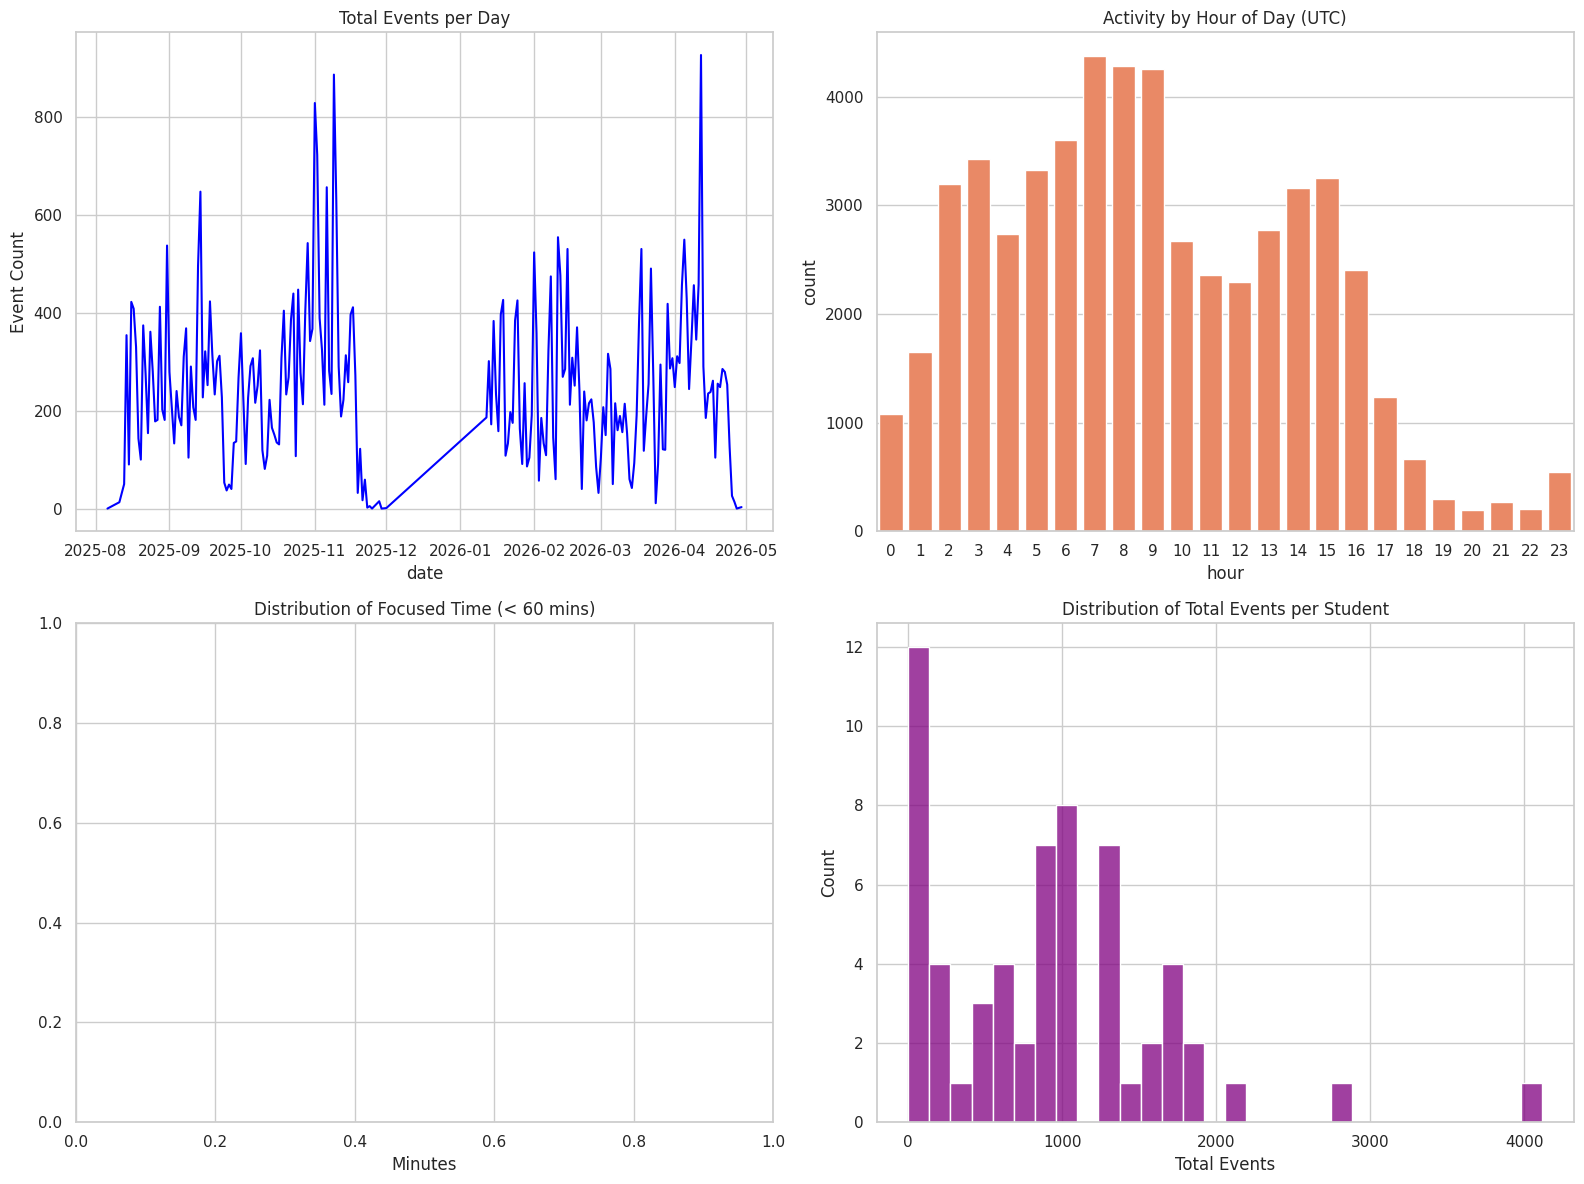

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Events over time
df.groupby('date').size().plot(ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Total Events per Day')
axes[0, 0].set_ylabel('Event Count')

# 2. Events by Hour of Day
sns.countplot(data=df, x='hour', color='coral', ax=axes[0, 1])
axes[0, 1].set_title('Activity by Hour of Day (UTC)')

# 3. Distribution of Focused Time (Capped at 60 mins for visualization)
sns.histplot(df[df['time_focused_minutes'] < 60]['time_focused_minutes'], bins=30, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of Focused Time (< 60 mins)')
axes[1, 0].set_xlabel('Minutes')

# 4. Events per Student
events_per_student = df.groupby('student_name').size()
sns.histplot(events_per_student, bins=30, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribution of Total Events per Student')
axes[1, 1].set_xlabel('Total Events')

plt.tight_layout()
plt.show()

In [40]:
import pandas as pd

print("=========================================")
print(" STEP 1: QUANTIFYING THE COVERAGE GAP")
print("=========================================\n")

# 1. Macro-Level Event Counts
total_pageviews = len(df[df['event'] == '$pageview'])
total_pageleaves = len(df[df['event'] == '$pageleave'])

missing_leaves = total_pageviews - total_pageleaves
missing_percentage = (missing_leaves / total_pageviews) * 100

print("--- Aggregate Event Counts ---")
print(f"Total $pageview events: {total_pageviews:,}")
print(f"Total $pageleave events: {total_pageleaves:,}")
print(f"Total Missing $pageleaves: {missing_leaves:,} ({missing_percentage:.1f}% of all views)\n")

# 2. Session-Level Orphan Analysis
sessions_with_view = set(df[df['event'] == '$pageview']['session_id'].dropna())
sessions_with_leave = set(df[df['event'] == '$pageleave']['session_id'].dropna())
orphaned_sessions = sessions_with_view - sessions_with_leave
orphan_rate = (len(orphaned_sessions) / len(sessions_with_view)) * 100

print("--- Session-Level Accuracy ---")
print(f"Sessions starting with a view: {len(sessions_with_view):,}")
print(f"Sessions ending with a leave:  {len(sessions_with_leave):,}")
print(f"Orphaned Sessions (No Exit):   {len(orphaned_sessions):,} ({orphan_rate:.1f}% of all view sessions)\n")

print("CONCLUSION :")
print(f"Because {orphan_rate:.1f}% of pageviews never record an exit event, any 'average time on page' calculation will systematically drop these sessions, heavily skewing the data.")

 STEP 1: QUANTIFYING THE COVERAGE GAP

--- Aggregate Event Counts ---
Total $pageview events: 14,466
Total $pageleave events: 12,852
Total Missing $pageleaves: 1,614 (11.2% of all views)

--- Session-Level Accuracy ---
Sessions starting with a view: 14,447
Sessions ending with a leave:  12,487
Orphaned Sessions (No Exit):   4,343 (30.1% of all view sessions)

CONCLUSION :
Because 30.1% of pageviews never record an exit event, any 'average time on page' calculation will systematically drop these sessions, heavily skewing the data.


In [37]:
import pandas as pd

print("=========================================")
print(" STEP 2: CALCULATING THE READ-TO-VIEW RATIO")
print("=========================================\n")

# 1. Filter for only pageviews and read events
view_read_df = df[df['event'].isin(['$pageview', 'read'])]

# 2. Pivot the data to get counts per pathname
page_stats = view_read_df.pivot_table(
    index='pathname',
    columns='event',
    values='distinct_id',
    aggfunc='count',
    fill_value=0
)

# 3. Calculate the true engagement ratio
# Handling potential division by zero if a page somehow has reads but no views
page_stats['read_to_view_ratio'] = page_stats['read'] / page_stats['$pageview'].replace(0, 1)
page_stats['engagement_rate_%'] = (page_stats['read_to_view_ratio'] * 100).round(1)

# 4. Filter out obscure pages (less than 50 views) to avoid noisy 100% ratios
popular_pages = page_stats[page_stats['$pageview'] >= 50].copy()

# 5. Sort to find the highest traffic pages and their actual engagement
top_traffic = popular_pages.sort_values(by='$pageview', ascending=False).head(10)

print("--- Top 10 Most Visited Pages & Their True Engagement ---")
print(top_traffic[['$pageview', 'read', 'engagement_rate_%']])

lowest_engagement = popular_pages.sort_values(by='engagement_rate_%', ascending=True).head(5)

print("\n--- Top 5 Lowest Engagement Pages (Background Tabs / Quick Checks) ---")
print(lowest_engagement[['$pageview', 'read', 'engagement_rate_%']])

 STEP 2: CALCULATING THE READ-TO-VIEW RATIO

--- Top 10 Most Visited Pages & Their True Engagement ---
event                                               $pageview  read  \
pathname                                                              
/course-ntw2029/schedule                                 3176  1576   
/                                                        2177   317   
/course-ntw2029/course-info/assignments/                  798   444   
/course-ntw2029/assignments/papers/p1-2510/               367   226   
/course-ntw2029/assignments/papers/p1-2520/               360   210   
/course-ntw2029/course-info/conferences/                  358   169   
/course-ntw2029/assignments/papers/p2-p08-full-...        311   196   
/course-ntw2029/assignments/papers/p2-p08-full-...        293   232   
/course-ntw2029/assignments/exercises/e02-expla...        293   135   
/course-ntw2029/assignments/papers/p2-p07-worki...        273   145   

event                                       

In [38]:
import pandas as pd
import numpy as np

print("=========================================")
print(" STEP 3: RECONSTRUCTING WEBSITE VISITS")
print("=========================================\n")

# 1. Sort data chronologically per student
df = df.sort_values(by=['person_id', 'timestamp']).reset_index(drop=True)

# 2. Calculate the time gap between consecutive events for each student
df['time_gap'] = df.groupby('person_id')['timestamp'].diff()

# 3. Define the gap threshold (30 minutes)
GAP_THRESHOLD_MINUTES = 30

# 4. A new visit starts if it's the first event (NaT) OR the gap exceeds the threshold
df['is_new_visit'] = (df['time_gap'].isna()) | (df['time_gap'].dt.total_seconds() > (GAP_THRESHOLD_MINUTES * 60))

# 5. Create a sequential visit number per student, then combine with person_id for a globally unique ID
df['visit_seq'] = df.groupby('person_id')['is_new_visit'].cumsum()
df['website_visit_id'] = df['person_id'].astype(str) + "_visit_" + df['visit_seq'].astype(str)

# 6. Compare the flawed PostHog sessions with our newly reconstructed visits
total_posthog_sessions = df['session_id'].nunique()
total_reconstructed_visits = df['website_visit_id'].nunique()
fragmentation_ratio = total_posthog_sessions / total_reconstructed_visits

print("--- Session vs. Visit Reconstruction Results ---")
print(f"Total Flawed PostHog Sessions (Page-level): {total_posthog_sessions:,}")
print(f"Total Reconstructed Website Visits (Trip-level): {total_reconstructed_visits:,}")
print(f"Average PostHog Sessions stitched into one True Visit: {fragmentation_ratio:.1f}")

events_per_visit = df.groupby('website_visit_id').size()
print("\n--- Events per Reconstructed Visit ---")
print(events_per_visit.describe().round(1)[['mean', '50%', '75%', 'max']])

 STEP 3: RECONSTRUCTING WEBSITE VISITS

--- Session vs. Visit Reconstruction Results ---
Total Flawed PostHog Sessions (Page-level): 17,353
Total Reconstructed Website Visits (Trip-level): 6,136
Average PostHog Sessions stitched into one True Visit: 2.8

--- Events per Reconstructed Visit ---
mean      8.8
50%       5.0
75%      11.0
max     204.0
dtype: float64


/tmp/ipykernel_1270/2330502546.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


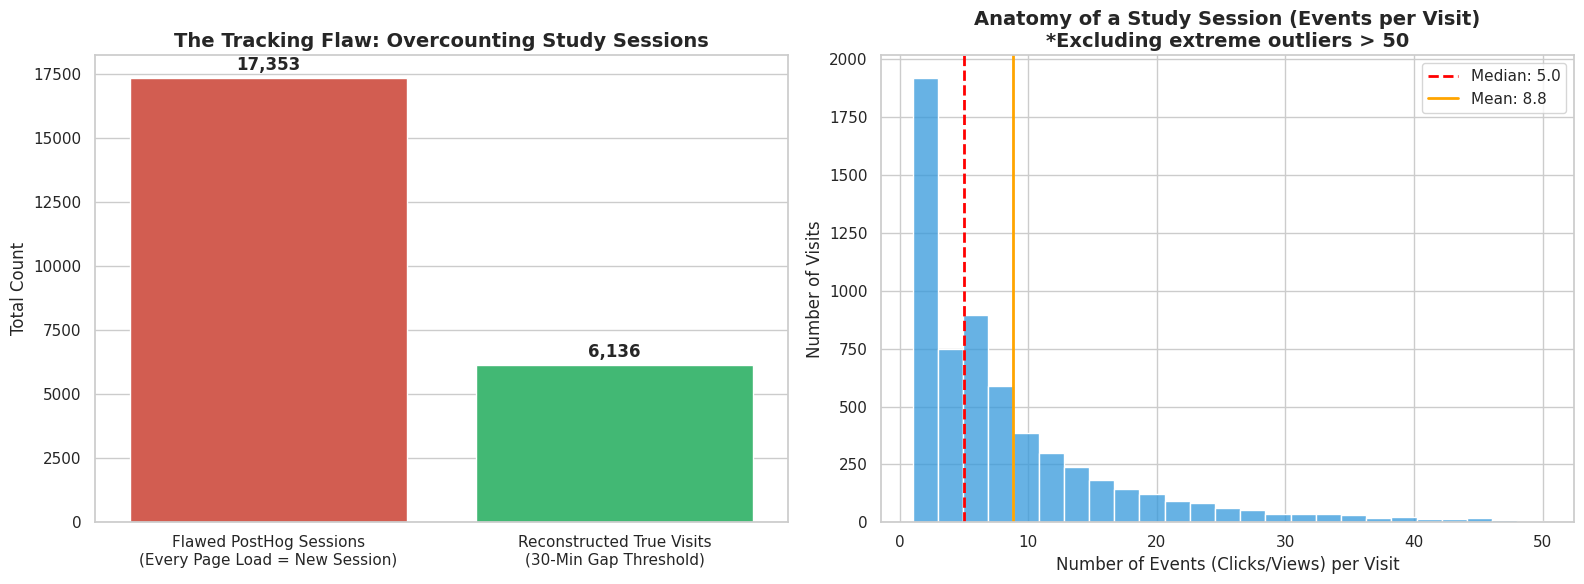

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Prepare data for the first plot (Fragmentation)
session_counts = {
    'Flawed PostHog Sessions\n(Every Page Load = New Session)': df['session_id'].nunique(),
    'Reconstructed True Visits\n(30-Min Gap Threshold)': df['website_visit_id'].nunique()
}

# 2. Prepare data for the second plot (Events per Visit)
events_per_visit = df.groupby('website_visit_id').size()

# 3. Create the figure and subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart for session vs visit count
sns.barplot(
    x=list(session_counts.keys()),
    y=list(session_counts.values()),
    ax=axes[0],
    palette=['#E74C3C', '#2ECC71']
)
axes[0].set_title('The Tracking Flaw: Overcounting Study Sessions', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Count', fontsize=12)

for i, v in enumerate(session_counts.values()):
    axes[0].text(i, v + 300, f"{v:,}", ha='center', fontweight='bold', fontsize=12)

# Plot 2: Histogram of events per visit
sns.histplot(events_per_visit[events_per_visit <= 50], bins=25, ax=axes[1], color='#3498DB')
axes[1].axvline(events_per_visit.median(), color='red', linestyle='--', linewidth=2, label=f'Median: {events_per_visit.median()}')
axes[1].axvline(events_per_visit.mean(), color='orange', linestyle='-', linewidth=2, label=f'Mean: {events_per_visit.mean():.1f}')

axes[1].set_title('Anatomy of a Study Session (Events per Visit)\n*Excluding extreme outliers > 50', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Events (Clicks/Views) per Visit', fontsize=12)
axes[1].set_ylabel('Number of Visits', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()